# Target variance per dataset

In [12]:
import os
import re
import pandas as pd
import numpy as np
import plotnine as pln
from sklearn.preprocessing import StandardScaler

In [13]:
def split_mut_sit(mutation):
    parts = re.match(r'([A-Za-z])(\d+)(\S)', mutation)
    if parts:
        return list(parts.groups())
    else:
        return [None, None, None]
    
split_mut_sit('H2T')

['H', '2', 'T']

In [14]:
data = pd.read_csv('../data/viral/metadata/BPP22_COAT_Tsuboyama.csv')
data[['wt', 'site', 'mut']] = data['mutant'].apply(lambda x: pd.Series(split_mut_sit(x)))
data['site'] = pd.Categorical(data['site'], categories=np.sort(data['site'].unique().astype(int)).astype(str))
#data['target'] = scaler.fit_transform(data['target'].to_frame()).squeeze()
data

,ID,mutant,num_mutations,target,sequence,wt,site,mut
0,BPP22_COAT_A12C,A12C,1,-0.260199,ITGDVSAANKDCIRKQMDAAASKGDVETYRKLKAKLKGIR,A,12,C
1,BPP22_COAT_A12D,A12D,1,0.082243,ITGDVSAANKDDIRKQMDAAASKGDVETYRKLKAKLKGIR,A,12,D
2,BPP22_COAT_A12E,A12E,1,0.131020,ITGDVSAANKDEIRKQMDAAASKGDVETYRKLKAKLKGIR,A,12,E
3,BPP22_COAT_A12F,A12F,1,-0.014158,ITGDVSAANKDFIRKQMDAAASKGDVETYRKLKAKLKGIR,A,12,F
4,BPP22_COAT_A12G,A12G,1,-0.399673,ITGDVSAANKDGIRKQMDAAASKGDVETYRKLKAKLKGIR,A,12,G
...,...,...,...,...,...,...,...,...
718,BPP22_COAT_Y29R,Y29R,1,-1.208937,ITGDVSAANKDAIRKQMDAAASKGDVETRRKLKAKLKGIR,Y,29,R
719,BPP22_COAT_Y29S,Y29S,1,-1.628483,ITGDVSAANKDAIRKQMDAAASKGDVETSRKLKAKLKGIR,Y,29,S
720,BPP22_COAT_Y29T,Y29T,1,-1.186837,ITGDVSAANKDAIRKQMDAAASKGDVETTRKLKAKLKGIR,Y,29,T
721,BPP22_COAT_Y29V,Y29V,1,-0.561113,ITGDVSAANKDAIRKQMDAAASKGDVETVRKLKAKLKGIR,Y,29,V


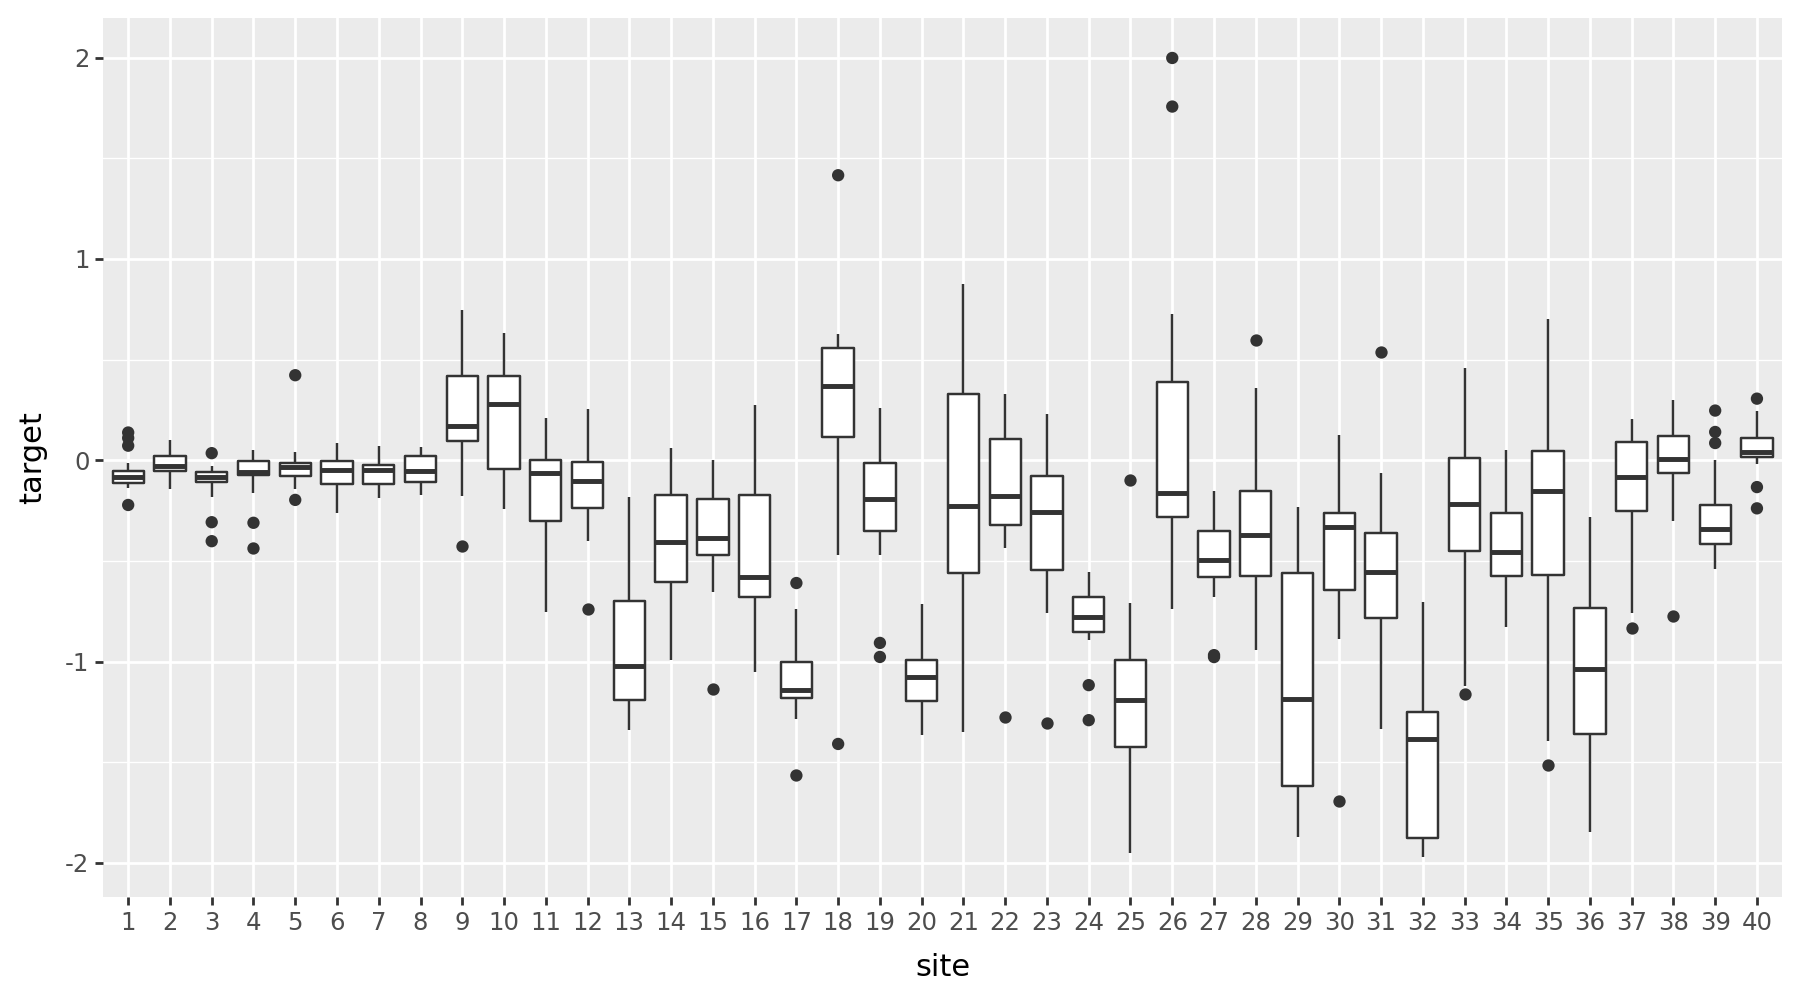

In [15]:
(
    pln.ggplot(data, pln.aes(x='site', y='target'))
    + pln.geom_boxplot()
    + pln.theme(figure_size=(9,5))
    )

In [16]:
global_std = data['target'].std()
grouped_data = data.groupby(['site'], as_index=False, observed=True)['target'].std()
M = grouped_data['target'].mean()
Std = grouped_data['target'].std()
print(f'Global Std: {global_std}, Site Mean: {M}, Site Std: {Std}')

grouped_data['ratio_std'] = grouped_data['target'] / global_std
grouped_data

Global Std: 0.541027719361465, Site Mean: 0.3067619292769151, Site Std: 0.17038228556261592


,site,target,ratio_std
0,1,0.089824,0.166024
1,2,0.064213,0.118687
2,3,0.102618,0.189672
3,4,0.120826,0.223327
4,5,0.123514,0.228295
5,6,0.097526,0.180261
6,7,0.077513,0.143269
7,8,0.075765,0.140039
8,9,0.276774,0.511571
9,10,0.291125,0.538097


/stor/work/Wilke/luiz/ViCAM/venv/lib/python3.10/site-packages/plotnine/layer.py:372: PlotnineWarning: geom_point : Removed 5 rows containing missing values.


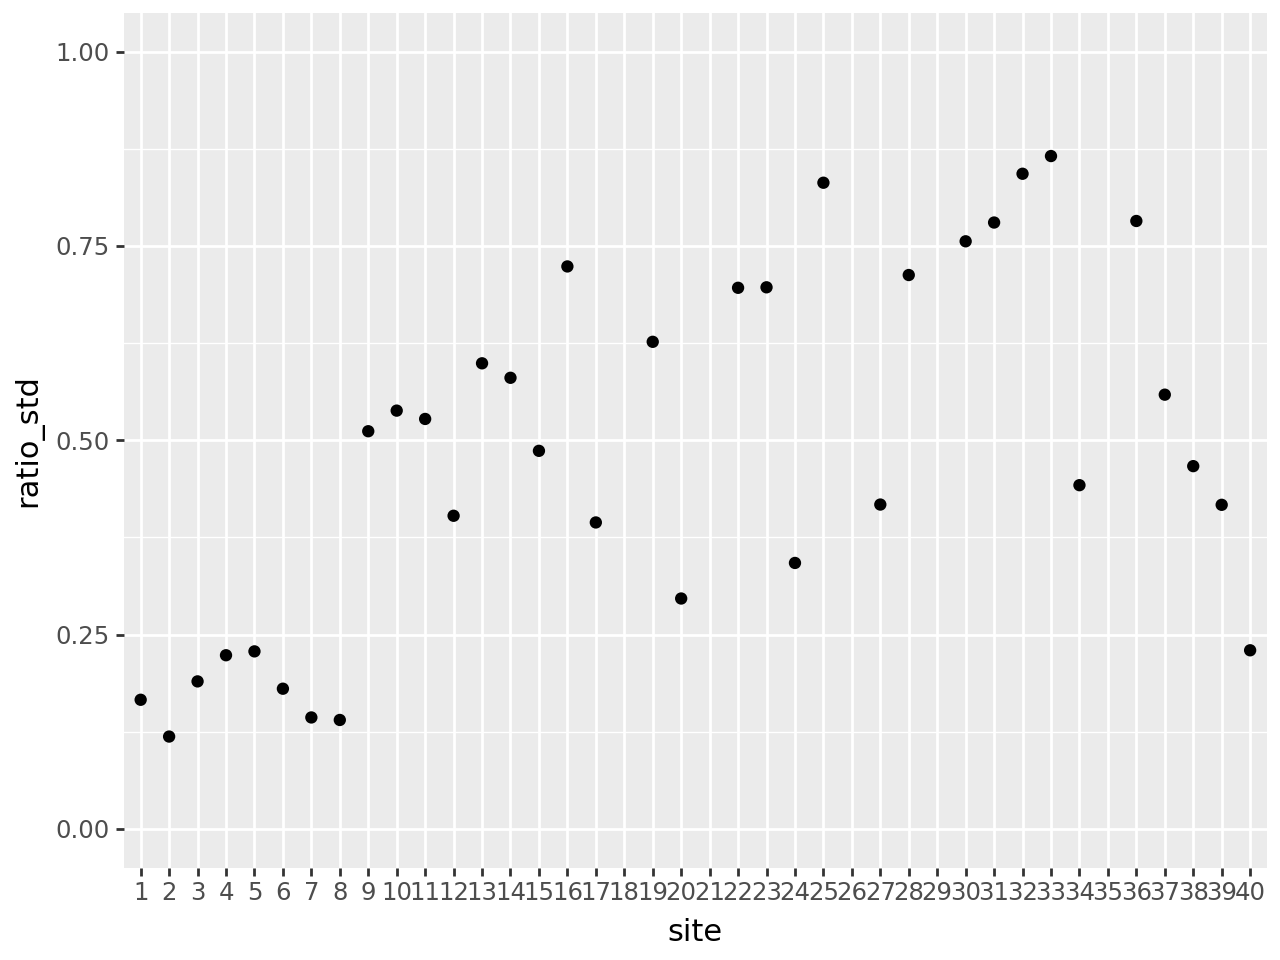

In [14]:
plot = (
    pln.ggplot(grouped_data, pln.aes(x='site', y='ratio_std'))
    + pln.geom_point()
    + pln.ylim(0,1)
    )

plot

In [42]:
stop

NameError: name 'stop' is not defined

# Z-score

In [ ]:
def zscore(x):
    z = (x - M) / Std
    return z

zscore(0.31)

np.float64(0.019004738153338762)

In [ ]:
grouped_data['zscore'] = grouped_data['target'].apply(zscore)
grouped_data

,site,target,zscore
0,1,0.089824,-1.273243
1,2,0.064213,-1.423557
2,3,0.102618,-1.198155
3,4,0.120826,-1.091287
4,5,0.123514,-1.075510
5,6,0.097526,-1.228036
6,7,0.077513,-1.345499
7,8,0.075765,-1.355757
8,9,0.276774,-0.176005
9,10,0.291125,-0.091773


In [ ]:
#sites = list(grouped_data.query('target >= @Std')['site'].values)
sites = list(grouped_data.query('zscore > 0')['site'].values)

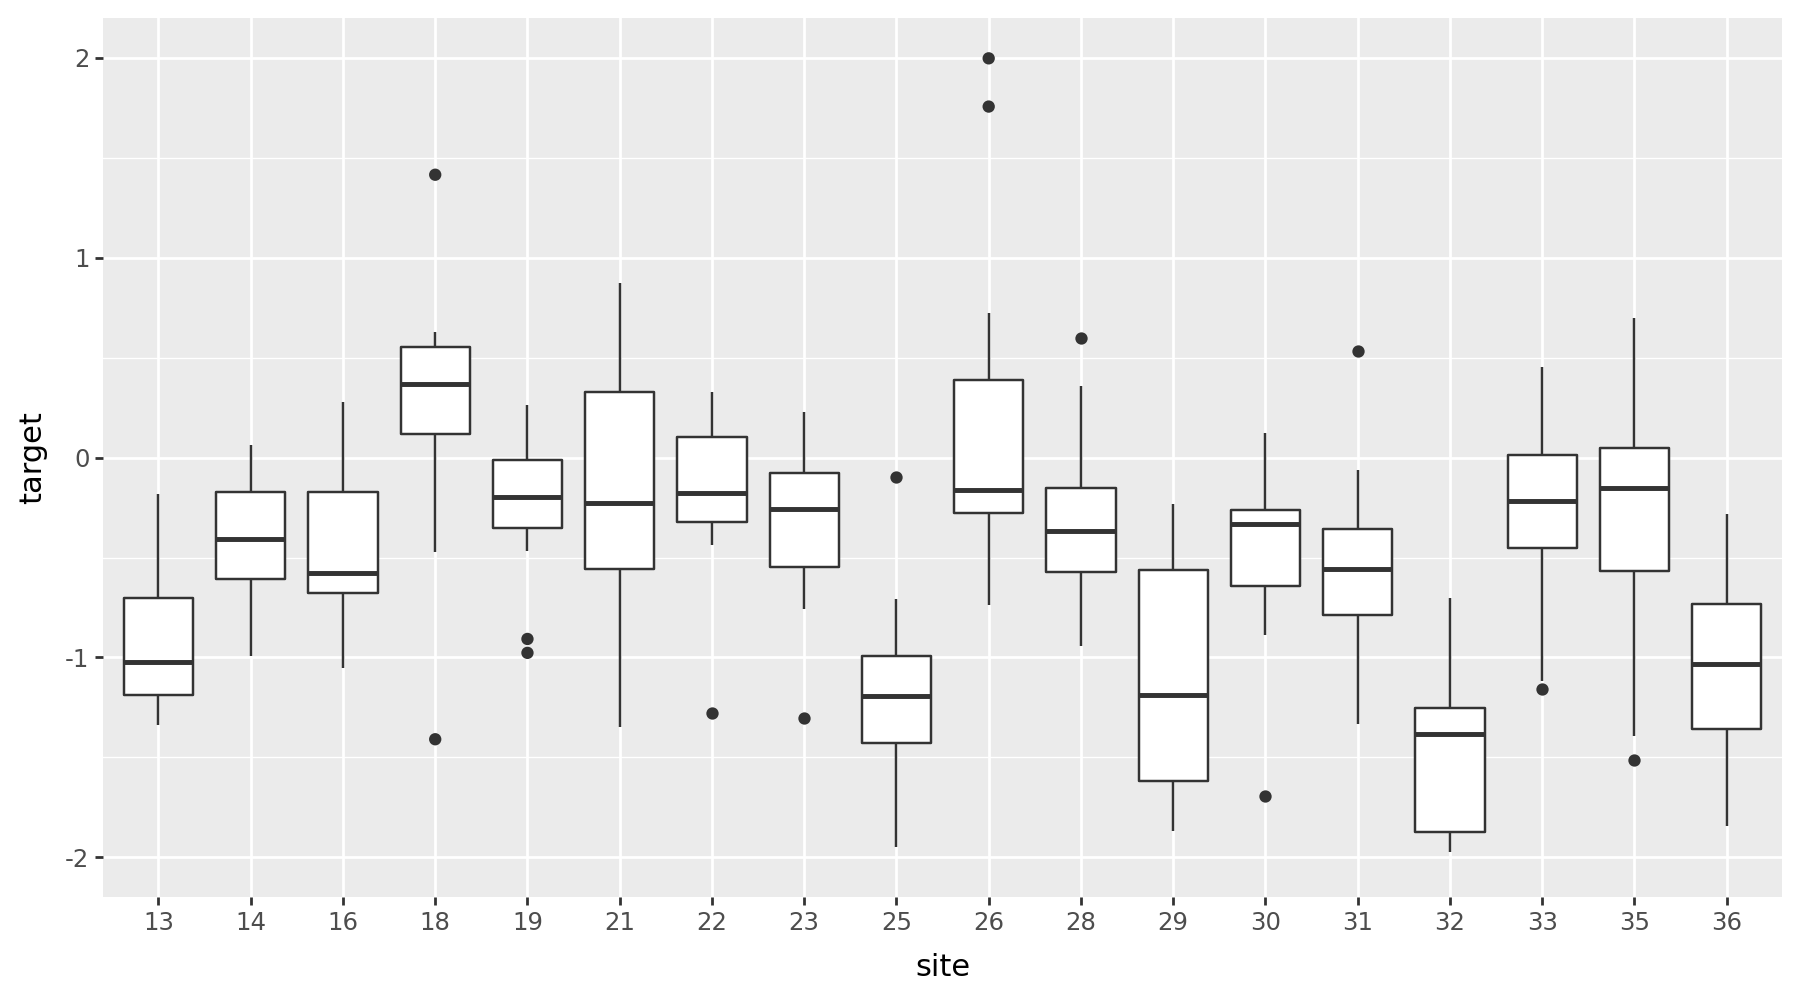

In [ ]:
(
    pln.ggplot(data.query('site in @sites'), pln.aes(x='site', y='target'))
    + pln.geom_boxplot()
    + pln.theme(figure_size=(9,5))
    + pln.ylim(-2, 2)
    )

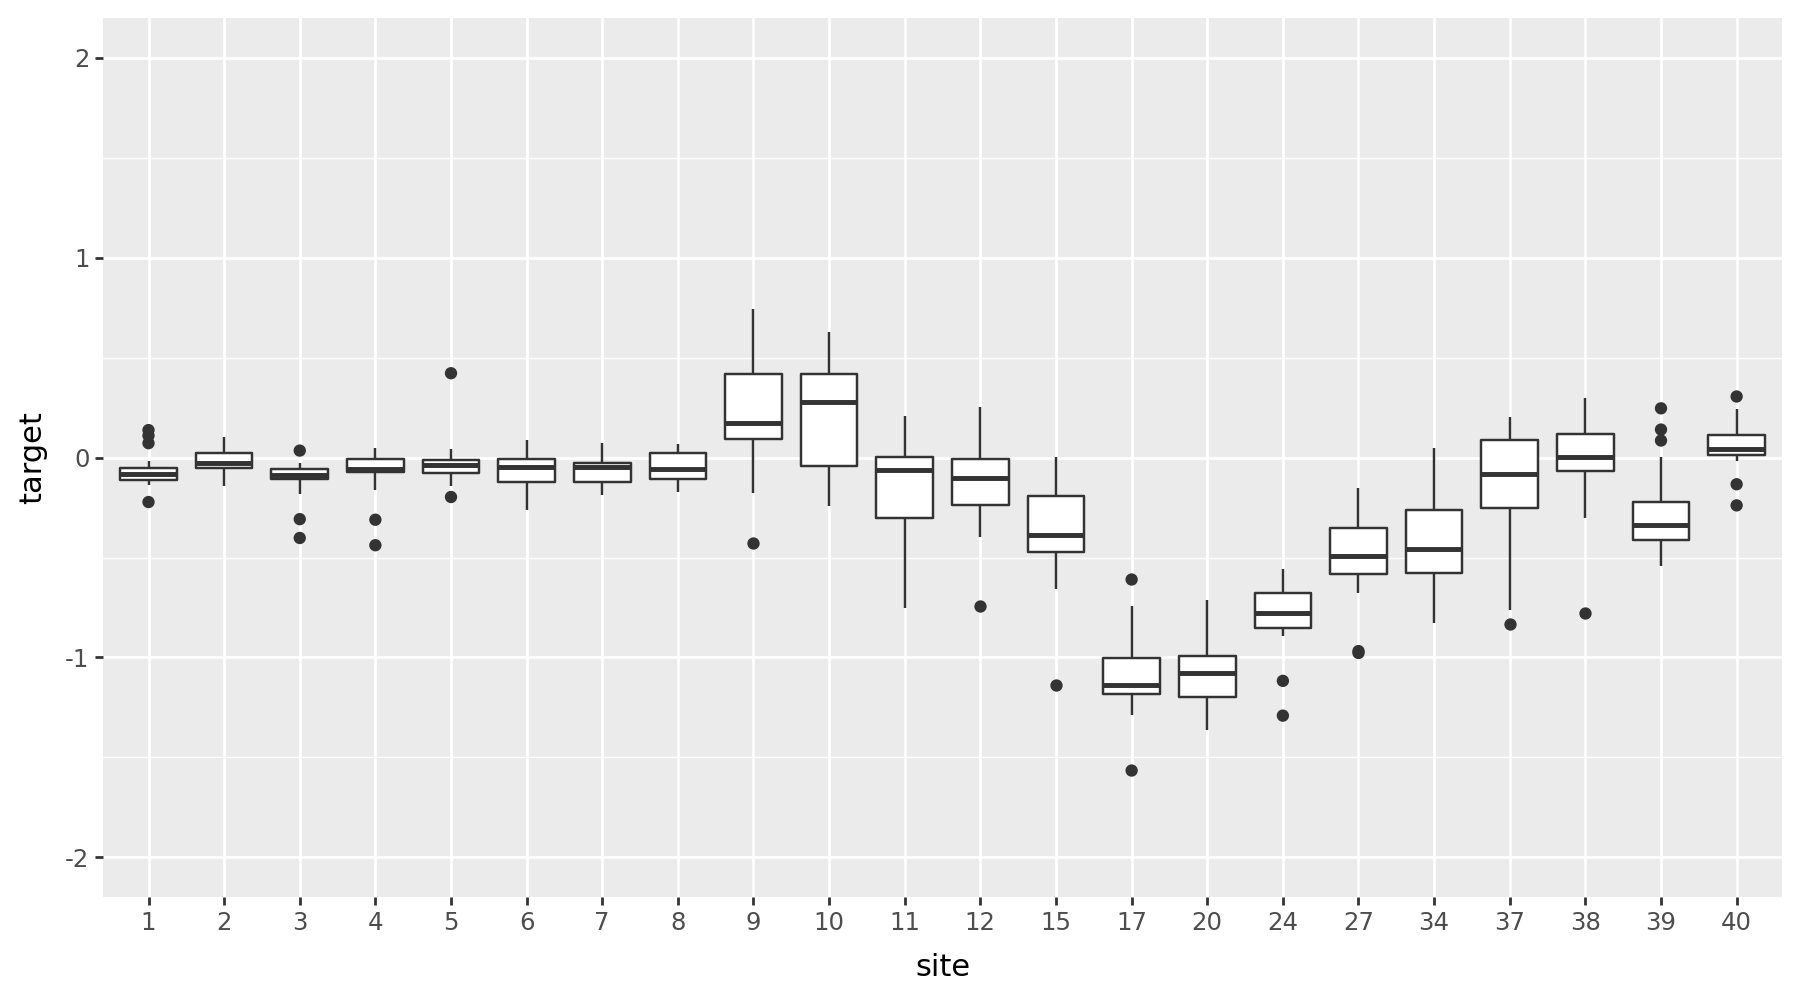

In [ ]:
(
    pln.ggplot(data.query('site not in @sites'), pln.aes(x='site', y='target'))
    + pln.geom_boxplot()
    + pln.theme(figure_size=(9,5))
    + pln.ylim(-2, 2)
    )

# Filtering dataset by variance

# Z-score

In [ ]:
def zscore(x):
    z = (x - M) / Std
    return z

In [17]:
def split_mut_sit(mutation):
    parts = re.match(r'([A-Za-z])(\d+)(\S)', mutation)
    if parts:
        return list(parts.groups())
    else:
        return [None, None, None]

In [ ]:
data = pd.read_csv('../data/viral/metadata/BPP22_COAT_Tsuboyama.csv')
# data = pd.read_csv('../data/viral/metadata/CVB3_3B_Alvarez.csv')
# data = pd.read_csv('../data/viral/metadata/IAV_H3_HA_Lee.csv')
data[['wt', 'site', 'mut']] = data['mutant'].apply(lambda x: pd.Series(split_mut_sit(x)))
grouped_data = data.groupby(['site'], as_index=False, observed=True)['target'].std()
M = grouped_data['target'].mean()
Std = grouped_data['target'].std()

grouped_data['zscore'] = grouped_data['target'].apply(zscore)
sites = list(grouped_data.query('zscore > 0')['site'].values)
#sites = list(grouped_data.query('target >= @Std')['site'].values)

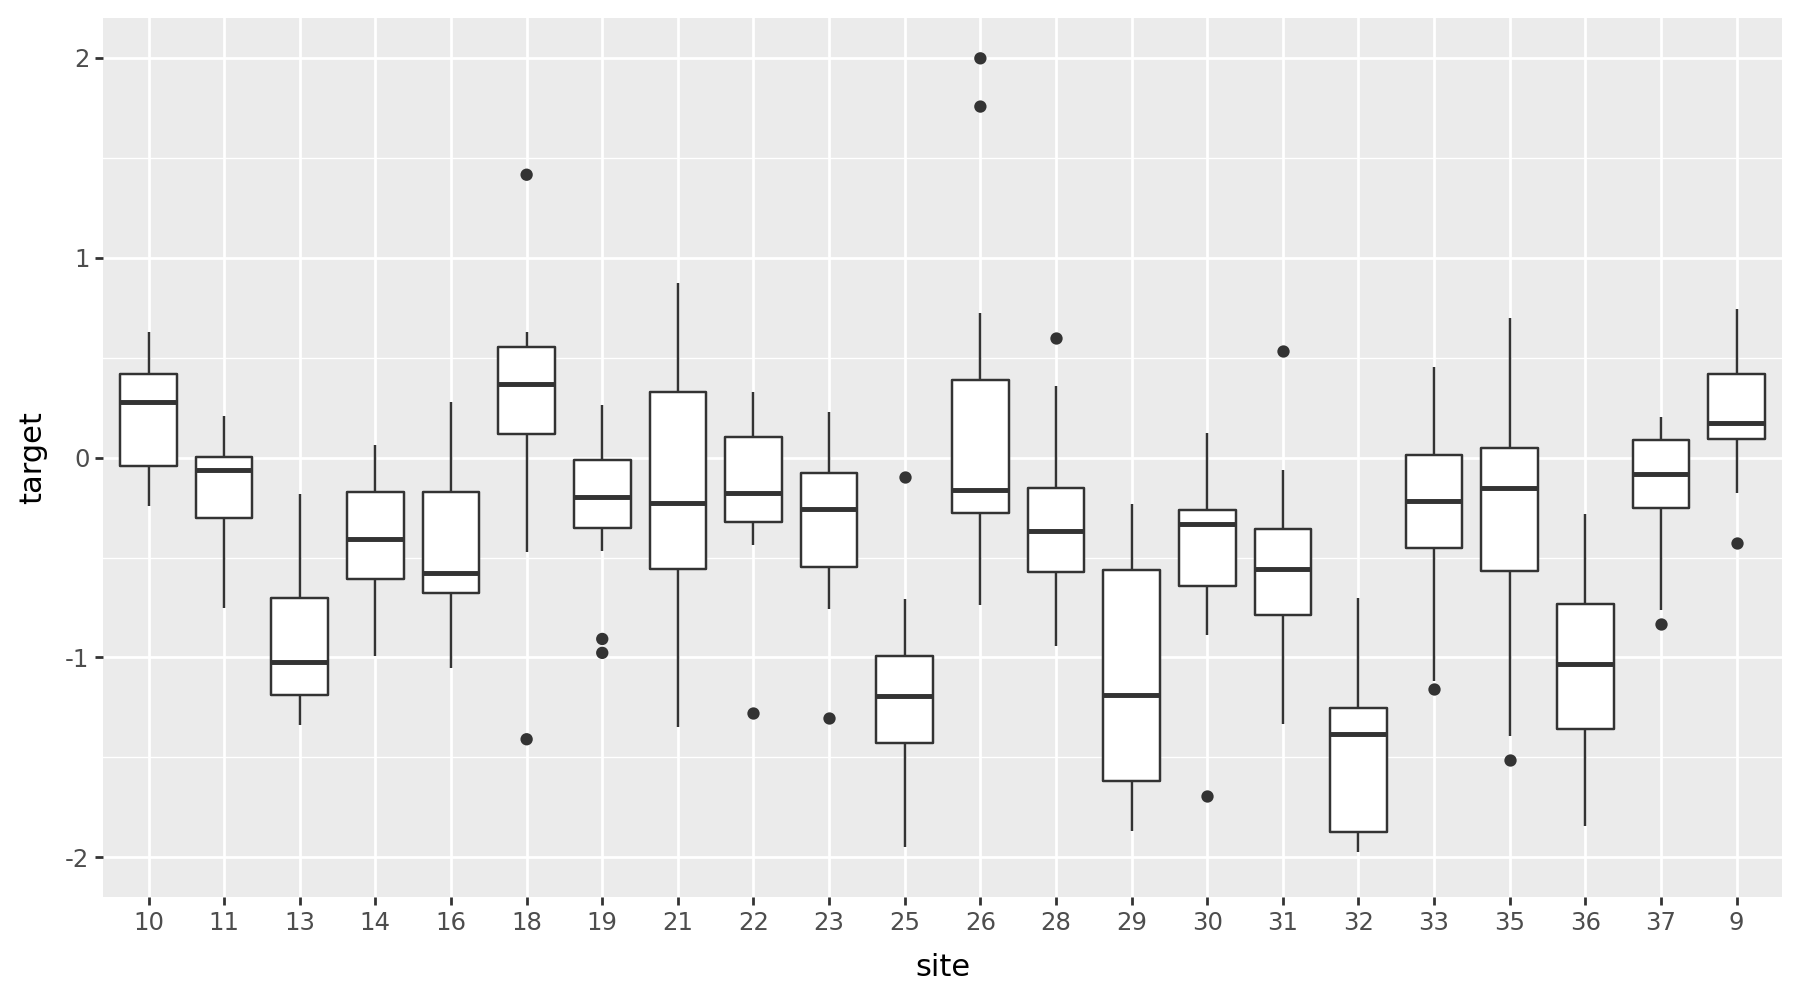

In [23]:
(
    pln.ggplot(data.query('site in @sites'), pln.aes(x='site', y='target'))
    + pln.geom_boxplot()
    + pln.theme(figure_size=(9,5))
    + pln.ylim(-2, 2)
    )

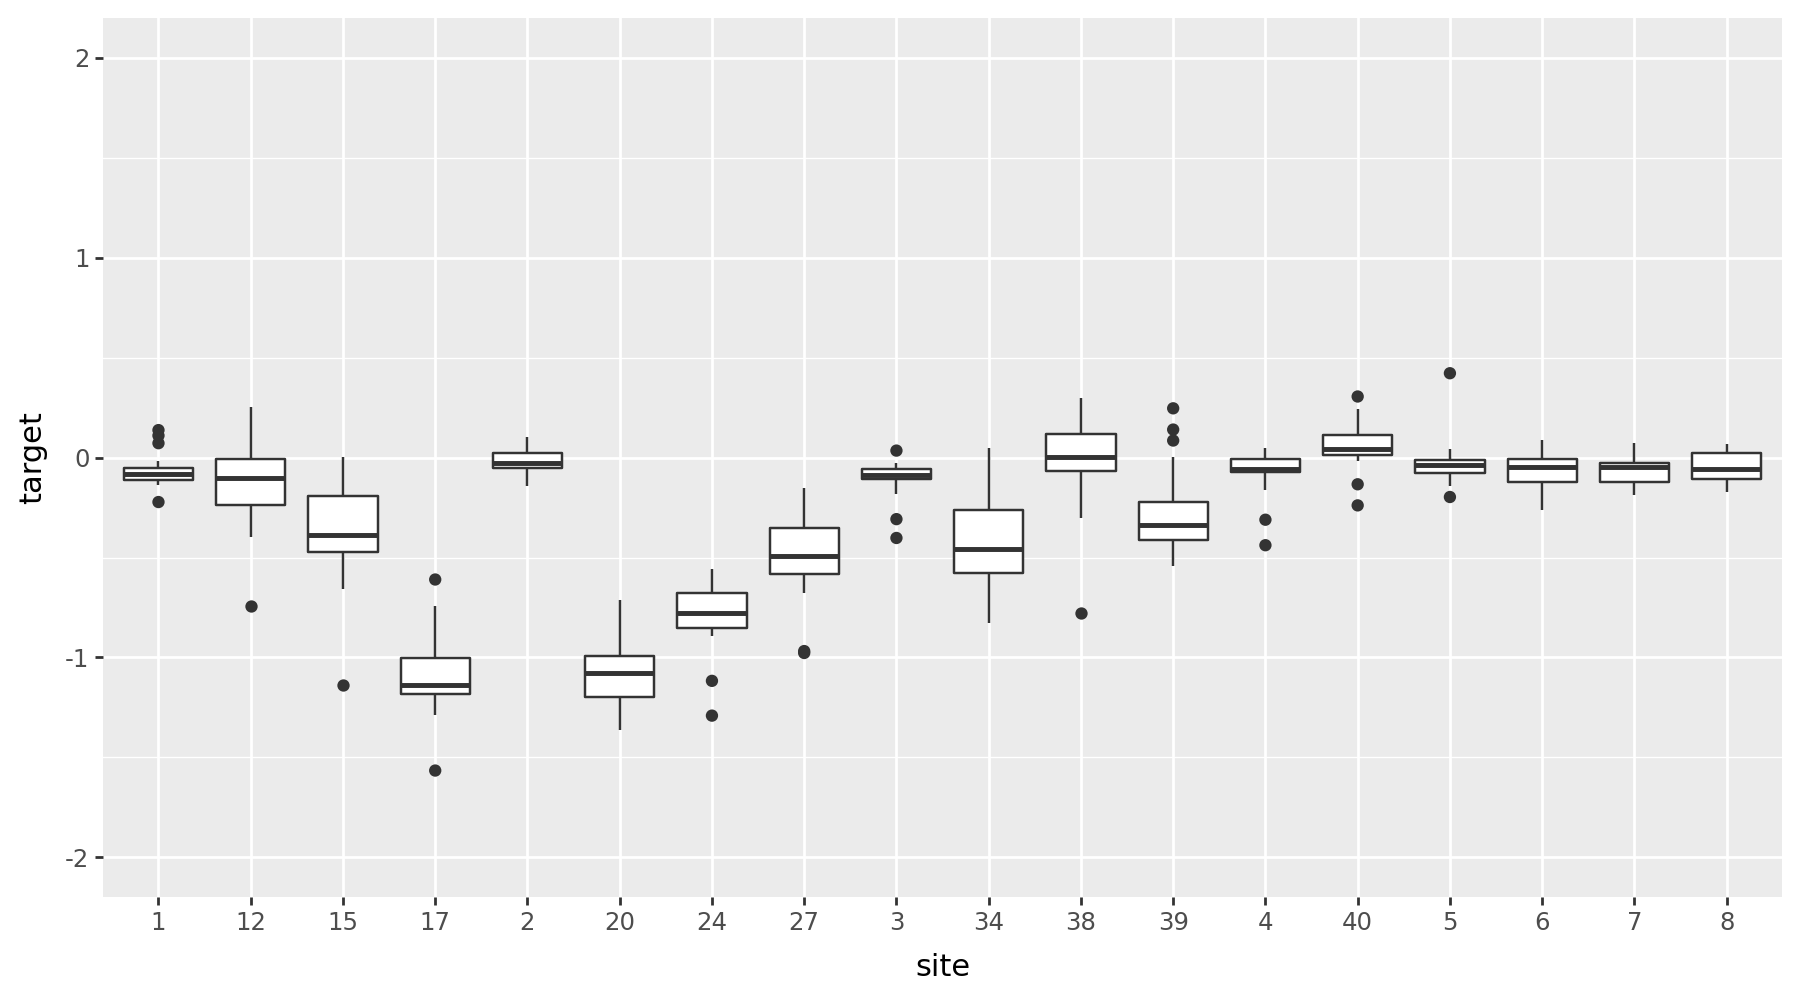

In [24]:
(
    pln.ggplot(data.query('site not in @sites'), pln.aes(x='site', y='target'))
    + pln.geom_boxplot()
    + pln.theme(figure_size=(9,5))
    + pln.ylim(-2, 2)
    )

In [ ]:
# filtering by z-score
for source in ['cellular', 'viral']:
    dir_path = f'../data/{source}/metadata/'
    for file in os.listdir(dir_path):
        print(f'Processing file {file}')
        data = pd.read_csv(f'../data/{source}/metadata/{file}')
        print(data.shape)
        data[['wt', 'site', 'mut']] = data['mutant'].apply(lambda x: pd.Series(split_mut_sit(x)))
        grouped_data = data.groupby(['site'], as_index=False, observed=True)['target'].std()
        M = grouped_data['target'].mean()
        Std = grouped_data['target'].std()
        grouped_data['zscore'] = grouped_data['target'].apply(zscore)
        sites = list(grouped_data.query('zscore > 0')['site'].values)
        data = data.query('site in @sites')
        print(data.shape)
        data.to_csv(f'../data/{source}/metadata_zscore_filtered/{file}')

# STD

In [25]:
data = pd.read_csv('../data/viral/metadata/BPP22_COAT_Tsuboyama.csv')
data[['wt', 'site', 'mut']] = data['mutant'].apply(lambda x: pd.Series(split_mut_sit(x)))

global_std = data['target'].std()

grouped_data = data.groupby(['site'], as_index=False, observed=True)['target'].std()
grouped_data['ratio_std'] = grouped_data['target'] / global_std

sites = list(grouped_data.query('ratio_std > 0.5')['site'].values)
grouped_data

,site,target,ratio_std
0,1,0.089824,0.166024
1,10,0.291125,0.538097
2,11,0.285329,0.527384
3,12,0.217921,0.402791
4,13,0.324061,0.598974
5,14,0.313978,0.580337
6,15,0.263130,0.486351
7,16,0.391500,0.723622
8,17,0.213267,0.394189
9,18,0.557932,1.031245


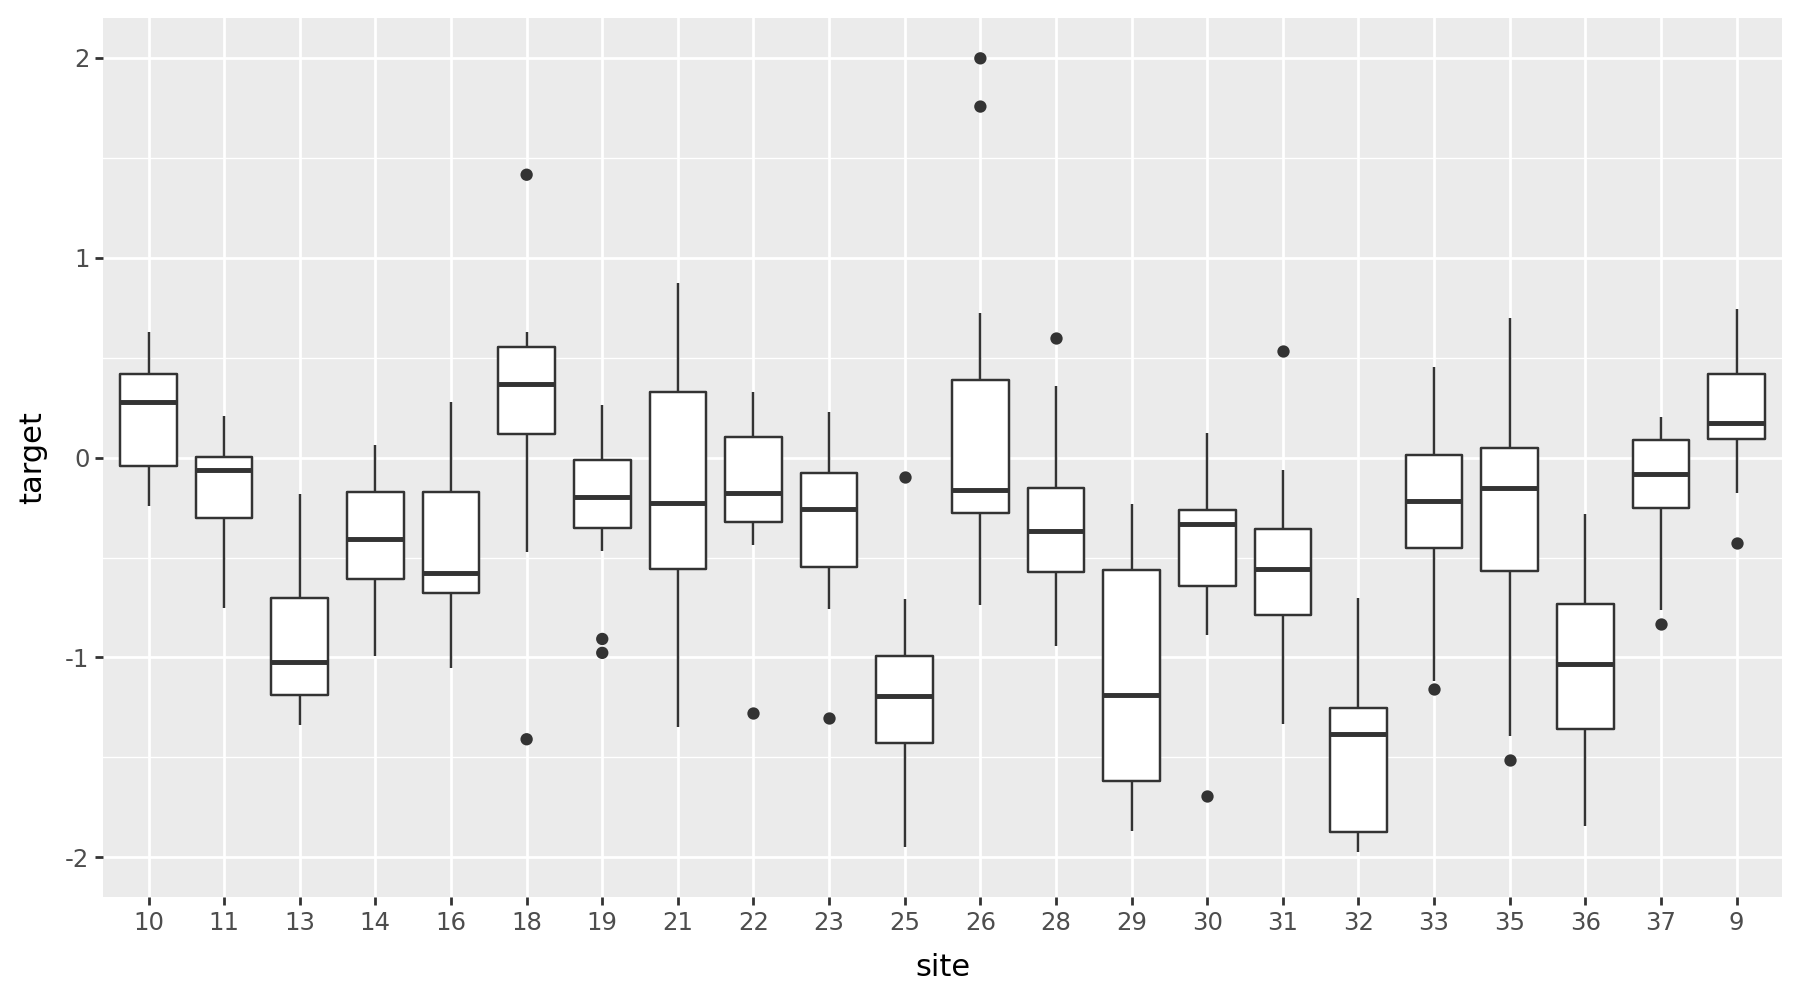

In [26]:
(
    pln.ggplot(data.query('site in @sites'), pln.aes(x='site', y='target'))
    + pln.geom_boxplot()
    + pln.theme(figure_size=(9,5))
    + pln.ylim(-2, 2)
    )

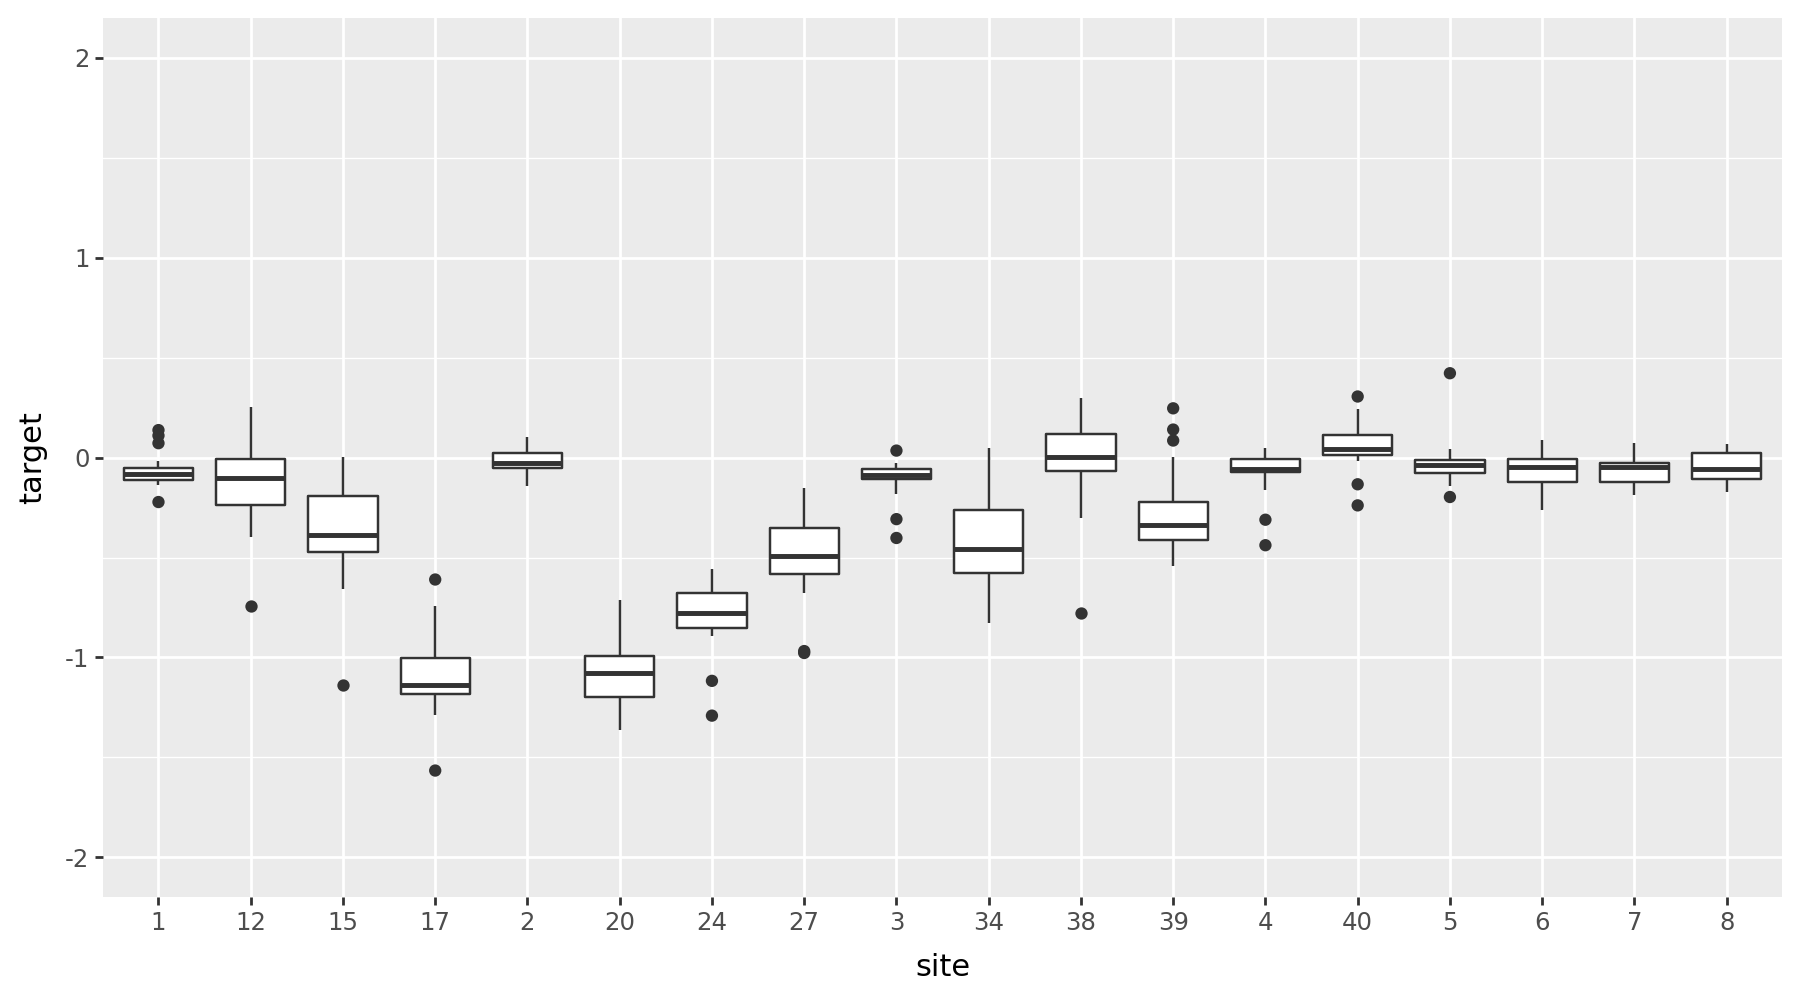

In [27]:
(
    pln.ggplot(data.query('site not in @sites'), pln.aes(x='site', y='target'))
    + pln.geom_boxplot()
    + pln.theme(figure_size=(9,5))
    + pln.ylim(-2, 2)
    )

In [28]:
# Filtering by values greater than 1 std from the entire data
for source in ['cellular', 'viral']:
    dir_path = f'../data/{source}/metadata/'
    for file in os.listdir(dir_path):
        print(f'Processing file {file}')
        data = pd.read_csv(f'../data/{source}/metadata/{file}')
        global_std = data['target'].std()
        print(data.shape)
        data[['wt', 'site', 'mut']] = data['mutant'].apply(lambda x: pd.Series(split_mut_sit(x)))
        grouped_data = data.groupby(['site'], as_index=False, observed=True)['target'].std()
        
        grouped_data['ratio_std'] = grouped_data['target'] / global_std
        sites = list(grouped_data.query('ratio_std > 0.5')['site'].values)
        data = data.query('site in @sites')
        print(data.shape)
        data.to_csv(f'../data/{source}/metadata_STD0.5_filtered/{file}')

Processing file TIM_THETH.csv
(1519, 5)
(1101, 8)
Processing file TIM_THEMA.csv
(1519, 5)
(1082, 8)
Processing file MK01_HUMAN_Johannessen.csv
(6809, 5)
(6657, 8)
Processing file IF1_ECOLI.csv
(1439, 5)
(679, 8)
Processing file TIM_SULSO.csv
(1519, 5)
(1082, 8)
Processing file RL401_YEAST_Fraser2016.csv
(1324, 5)
(876, 8)
Processing file RASH_HUMAN_Kuriyan.csv
(3134, 5)
(1634, 8)
Processing file MTH3_HAEAESTABILIZED_Tawfik2015.csv
(1777, 5)
(1152, 8)
Processing file AMIE_PSEAE_Whitehead.csv
(6568, 5)
(4473, 8)
Processing file TPMT_HUMAN_Fowler2018.csv
(3984, 5)
(3490, 8)
Processing file PTEN_HUMAN_Fowler2018.csv
(4229, 5)
(3269, 8)
Processing file BG_STRSQ_hmmerbit.csv
(3500, 5)
(2194, 8)
Processing file DLG4_RAT_Ranganathan2012.csv
(1659, 5)
(680, 8)
Processing file TPK1_HUMAN_Roth2017.csv
(3424, 5)
(3372, 8)
Processing file GAL4_YEAST_Shendure2015.csv
(1195, 5)
(991, 8)
Processing file UBE4B_MOUSE_Klevit2013_singles.csv
(899, 5)
(683, 8)
Processing file PABP_YEAST_Fields2013_singles.

# Results from the filtered data

In [1]:
import os
import pandas as pd
import plotnine as pln

In [2]:
def read_results(res_dir_path, model_name):
    res = pd.DataFrame()
    for file in os.listdir(res_dir_path):
        if file.endswith('.csv'):
            dataset = file.split('.')[0]
            df = pd.read_csv(os.path.join(res_dir_path, file), index_col=0)
            df['Dataset'] = dataset
            res = pd.concat([res, df], ignore_index=True)
    res['Model'] = model_name
    return res

## Z-Score

In [3]:
lassoCV = pd.DataFrame()
for model in ['esm2_650m', 'esm2_viral_650m_MP15']:
    for source in ['viral', 'cellular']:
        for method in ['pool_split', 'site_split']:
            res_dir_path = f'../experiments/lassoCV_zscore_filtered/{model}/{source}/{method}/'
            res = read_results(res_dir_path, model)
            res['Source'] = source
            res['Split'] = method
            lassoCV = pd.concat([lassoCV, res], ignore_index=True)

lassoCV

,Model,Fold,R2_score_train,MAE_score_train,RMSE_score_train,R2_score_test,MAE_score_test,RMSE_score_test,rho_score_train,rho_score_test,num_nonzero_coefs,Dataset,Source,Split
0,esm2_650m,1,0.343358,0.661983,0.807111,0.215551,0.740537,0.898124,0.594085,0.467077,510,EV_CAPSD_Bakhache,viral,pool_split
1,esm2_650m,2,0.326074,0.676705,0.821081,0.202523,0.733463,0.892302,0.580095,0.453228,440,EV_CAPSD_Bakhache,viral,pool_split
2,esm2_650m,3,0.355829,0.660131,0.801851,0.185322,0.747703,0.905943,0.605899,0.446334,527,EV_CAPSD_Bakhache,viral,pool_split
3,esm2_650m,1,0.408209,0.624423,0.769194,0.285372,0.682196,0.845716,0.647598,0.546643,489,IAV_RDRP_Li,viral,pool_split
4,esm2_650m,2,0.416337,0.617035,0.761764,0.305763,0.687780,0.842361,0.654706,0.560640,499,IAV_RDRP_Li,viral,pool_split
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
883,esm2_viral_650m_MP15,2,0.267157,0.738990,0.855326,0.085320,0.797786,0.951890,0.502587,0.340541,21,HSP82_YEAST_Bolon2016,cellular,site_split
884,esm2_viral_650m_MP15,3,0.238671,0.763968,0.873901,-0.031616,0.888006,1.004755,0.467913,0.100089,18,HSP82_YEAST_Bolon2016,cellular,site_split
885,esm2_viral_650m_MP15,1,0.128672,0.803948,0.934894,-0.018976,0.855136,1.002921,0.391690,0.119228,26,BG_STRSQ_hmmerbit,cellular,site_split
886,esm2_viral_650m_MP15,2,0.104079,0.811069,0.940498,-0.000960,0.853457,1.015456,0.349109,0.198661,25,BG_STRSQ_hmmerbit,cellular,site_split


In [4]:
res_avg = pd.DataFrame()
for source in ['viral', 'cellular']:
    for method in ['pool_split', 'site_split']:
        res_dir_path = f'../experiments/AVG_zscore_filtered/{source}/{method}/'
        res = read_results(res_dir_path, model)
        res['Source'] = source
        res['Split'] = method
        res['Model'] = 'AVG_zscore'
        res_avg = pd.concat([res_avg, res], ignore_index=True)

res_avg

,Model,Fold,R2_score_train,MAE_score_train,RMSE_score_train,R2_score_test,MAE_score_test,RMSE_score_test,rho_score_train,rho_score_test,Dataset,Source,Split
0,AVG_zscore,1,0.137916,0.820909,0.936429,-0.079473,0.893570,1.001738,0.357455,0.107341,CVB3_2B_Alvarez,viral,pool_split
1,AVG_zscore,2,0.105895,0.848268,0.952617,0.045480,0.838537,0.943766,0.319010,0.221669,CVB3_2B_Alvarez,viral,pool_split
2,AVG_zscore,3,0.112925,0.832703,0.935428,0.034562,0.882898,1.004153,0.322010,0.233662,CVB3_2B_Alvarez,viral,pool_split
3,AVG_zscore,1,0.234835,0.705533,0.864925,-0.203448,0.924910,1.095491,0.470497,0.154857,CVB3_3B_Alvarez,viral,pool_split
4,AVG_zscore,2,0.187121,0.785075,0.921658,0.265921,0.641184,0.775774,0.425798,0.522489,CVB3_3B_Alvarez,viral,pool_split
...,...,...,...,...,...,...,...,...,...,...,...,...,...
439,AVG_zscore,2,0.000000,0.932787,1.025605,-0.000644,0.828580,0.903070,NaN,NaN,RL401_YEAST_Bolon2014,cellular,site_split
440,AVG_zscore,3,0.000000,0.878370,0.969783,-0.009681,1.012512,1.104742,NaN,NaN,RL401_YEAST_Bolon2014,cellular,site_split
441,AVG_zscore,1,0.000000,0.883108,0.996252,-0.030007,0.914016,1.016414,NaN,NaN,RL401_YEAST_Bolon2013,cellular,site_split
442,AVG_zscore,2,0.000000,0.902097,1.009528,-0.001487,0.858026,0.963438,NaN,NaN,RL401_YEAST_Bolon2013,cellular,site_split


In [5]:
res = pd.concat([res_avg, lassoCV.drop('num_nonzero_coefs', axis=1)])
res = res.groupby(['Model', 'Dataset', 'Source', 'Split'], as_index=False).mean()
res = res.query('Split == "pool_split"')
res

,Model,Dataset,Source,Split,Fold,R2_score_train,MAE_score_train,RMSE_score_train,R2_score_test,MAE_score_test,RMSE_score_test,rho_score_train,rho_score_test
0,AVG_zscore,AMIE_PSEAE_Whitehead,cellular,pool_split,2.0,0.285681,0.681469,0.850729,0.136017,0.734350,0.904019,0.488901,0.330563
2,AVG_zscore,B3VI55_LIPSTSTABLE,cellular,pool_split,2.0,0.187039,0.731662,0.900819,0.080191,0.782829,0.960237,0.419114,0.312670
4,AVG_zscore,B3VI55_LIPST_Whitehead2015,cellular,pool_split,2.0,0.271736,0.644528,0.856177,0.146888,0.682084,0.909834,0.476484,0.346839
6,AVG_zscore,BG_STRSQ_hmmerbit,cellular,pool_split,2.0,0.206686,0.732302,0.891036,-0.154062,0.877789,1.070810,0.420401,0.068980
8,AVG_zscore,BLAT_ECOLX_Ostermeier2014,cellular,pool_split,2.0,0.363505,0.641079,0.800715,0.276018,0.674813,0.837365,0.614952,0.519597
...,...,...,...,...,...,...,...,...,...,...,...,...,...
434,esm2_viral_650m_MP15,TPK1_HUMAN_Roth2017,cellular,pool_split,2.0,0.060535,0.841796,0.972727,0.003500,0.834459,0.981290,0.247630,0.107339
436,esm2_viral_650m_MP15,TPMT_HUMAN_Fowler2018,cellular,pool_split,2.0,0.568094,0.509773,0.655753,0.350862,0.629530,0.810971,0.732161,0.560228
438,esm2_viral_650m_MP15,UBC9_HUMAN_Roth2017,cellular,pool_split,2.0,0.415929,0.610358,0.767644,0.223658,0.683737,0.861797,0.663871,0.479699
440,esm2_viral_650m_MP15,UBE4B_MOUSE_Klevit2013_singles,cellular,pool_split,2.0,0.110525,0.742122,0.961103,-0.002670,0.704449,0.897791,0.354881,0.248144


In [6]:
rename_map = {
    'esm2_viral_650m_MP15':'esm2_viral_partial', 
    'esm2_viral_650m_MP15':'esm2_viral_full',
    'pool_split':'pooled',
    'site_split':'site',
    }

res.replace(rename_map, inplace=True)
res

,Model,Dataset,Source,Split,Fold,R2_score_train,MAE_score_train,RMSE_score_train,R2_score_test,MAE_score_test,RMSE_score_test,rho_score_train,rho_score_test
0,AVG_zscore,AMIE_PSEAE_Whitehead,cellular,pooled,2.0,0.285681,0.681469,0.850729,0.136017,0.734350,0.904019,0.488901,0.330563
2,AVG_zscore,B3VI55_LIPSTSTABLE,cellular,pooled,2.0,0.187039,0.731662,0.900819,0.080191,0.782829,0.960237,0.419114,0.312670
4,AVG_zscore,B3VI55_LIPST_Whitehead2015,cellular,pooled,2.0,0.271736,0.644528,0.856177,0.146888,0.682084,0.909834,0.476484,0.346839
6,AVG_zscore,BG_STRSQ_hmmerbit,cellular,pooled,2.0,0.206686,0.732302,0.891036,-0.154062,0.877789,1.070810,0.420401,0.068980
8,AVG_zscore,BLAT_ECOLX_Ostermeier2014,cellular,pooled,2.0,0.363505,0.641079,0.800715,0.276018,0.674813,0.837365,0.614952,0.519597
...,...,...,...,...,...,...,...,...,...,...,...,...,...
434,esm2_viral_full,TPK1_HUMAN_Roth2017,cellular,pooled,2.0,0.060535,0.841796,0.972727,0.003500,0.834459,0.981290,0.247630,0.107339
436,esm2_viral_full,TPMT_HUMAN_Fowler2018,cellular,pooled,2.0,0.568094,0.509773,0.655753,0.350862,0.629530,0.810971,0.732161,0.560228
438,esm2_viral_full,UBC9_HUMAN_Roth2017,cellular,pooled,2.0,0.415929,0.610358,0.767644,0.223658,0.683737,0.861797,0.663871,0.479699
440,esm2_viral_full,UBE4B_MOUSE_Klevit2013_singles,cellular,pooled,2.0,0.110525,0.742122,0.961103,-0.002670,0.704449,0.897791,0.354881,0.248144


In [7]:
res_pivot = pd.pivot_table(res, index=['Dataset', 'Source', 'Split'], columns='Model', values='R2_score_test').reset_index()
res_pivot 

Model,Dataset,Source,Split,AVG_zscore,esm2_650m,esm2_viral_full
0,AMIE_PSEAE_Whitehead,cellular,pooled,0.136017,0.407670,0.306516
1,B3VI55_LIPSTSTABLE,cellular,pooled,0.080191,0.407272,0.259979
2,B3VI55_LIPST_Whitehead2015,cellular,pooled,0.146888,0.277422,0.116297
3,BG_STRSQ_hmmerbit,cellular,pooled,-0.154062,0.323052,0.098595
4,BLAT_ECOLX_Ostermeier2014,cellular,pooled,0.276018,0.665248,0.452801
...,...,...,...,...,...,...
69,TPK1_HUMAN_Roth2017,cellular,pooled,-0.101294,0.020977,0.003500
70,TPMT_HUMAN_Fowler2018,cellular,pooled,0.180043,0.412636,0.350862
71,UBC9_HUMAN_Roth2017,cellular,pooled,0.109940,0.319626,0.223658
72,UBE4B_MOUSE_Klevit2013_singles,cellular,pooled,-0.336568,0.045967,-0.002670


In [8]:
res_pivot['diff'] = res_pivot['AVG_zscore'] - res_pivot['esm2_650m']
res_pivot.query("diff > 0.01")

Model,Dataset,Source,Split,AVG_zscore,esm2_650m,esm2_viral_full,diff
27,HIV1_BF520_ENV_Haddox,viral,pooled,0.412889,0.369774,0.409213,0.043115
35,IAV_H3_NP_Doud,viral,pooled,0.394789,0.358109,0.355028,0.036680
39,IAV_PB2_Soh,viral,pooled,0.326128,0.289932,0.288749,0.036195
55,RsYN04_RBD_Starr,viral,pooled,0.477054,0.311260,0.359291,0.165794
61,SARS2_PRD0038_RBD_Starr,viral,pooled,0.427445,0.282862,0.618128,0.144583


/stor/work/Wilke/luiz/ViCAM/venv/lib/python3.10/site-packages/plotnine/layer.py:372: PlotnineWarning: geom_point : Removed 3 rows containing missing values.


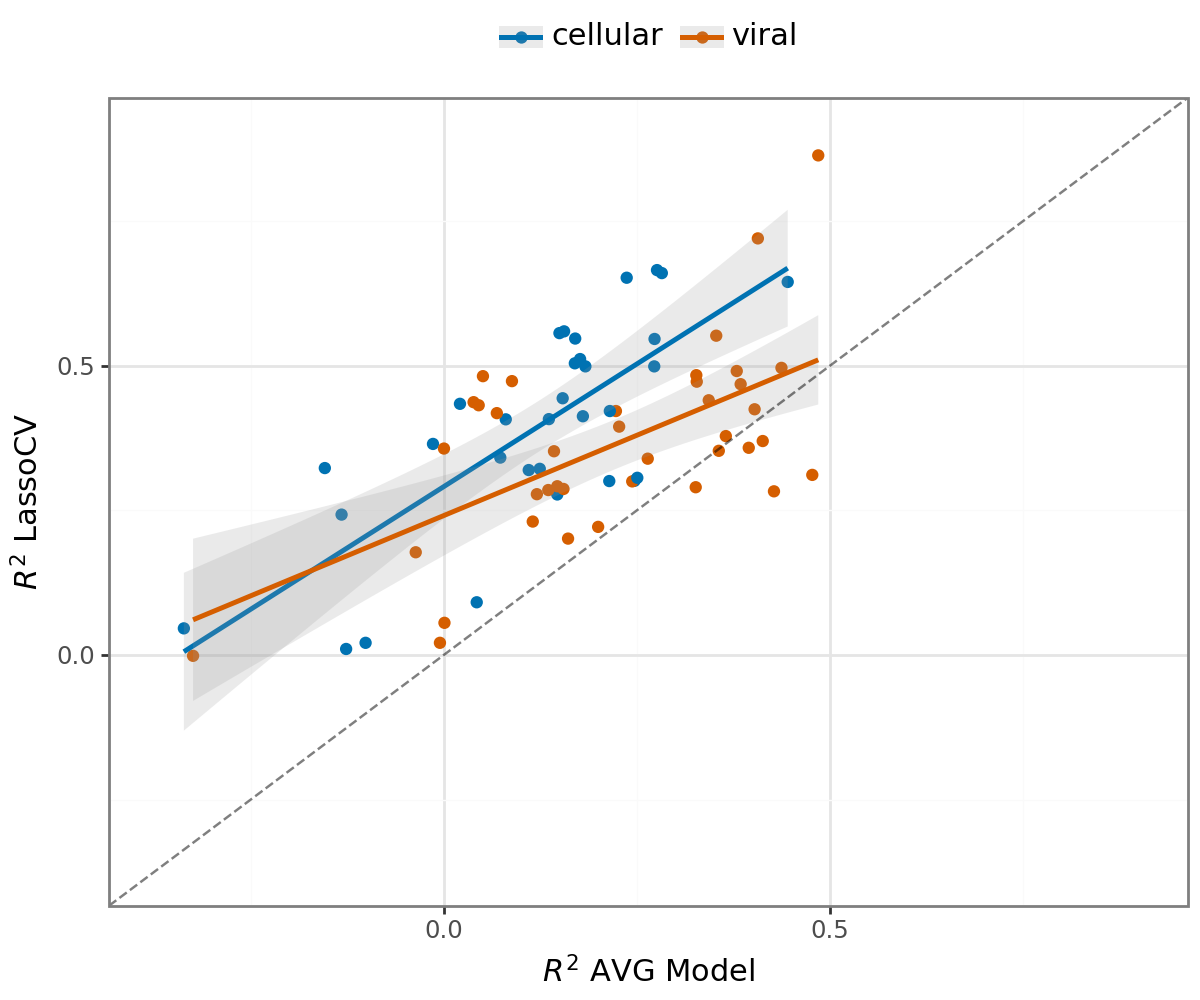

In [9]:
plot = (
    pln.ggplot(res_pivot, pln.aes(y='esm2_650m', x='AVG_zscore', color='Source'))
    + pln.scale_color_manual(values={"viral": "#D55E00", "cellular": "#0072B2"})
    + pln.geom_point()
    + pln.geom_smooth(method='lm', se=True,alpha=.2)
    + pln.theme_bw(11)
    + pln.geom_abline(intercept=0, alpha=0.5, linetype='dashed')
    + pln.theme(
        figure_size=(6,5),
        legend_position='top',
        legend_text=pln.element_text(size=11),
        legend_title=pln.element_blank()
    )
    #+ pln.facet_wrap('~Model', scales='fixed')
    + pln.xlim(-0.37, 0.9)
    + pln.ylim(-0.37, 0.9)
    + pln.labs(
        y="$R^2$ LassoCV",
        x="$R^2$ AVG Model"
    )
    )

plot#.save('../experiments/AVG/AVG_x_lassCV.png', dpi=600)

/stor/work/Wilke/luiz/ViCAM/venv/lib/python3.10/site-packages/plotnine/layer.py:372: PlotnineWarning: geom_point : Removed 3 rows containing missing values.


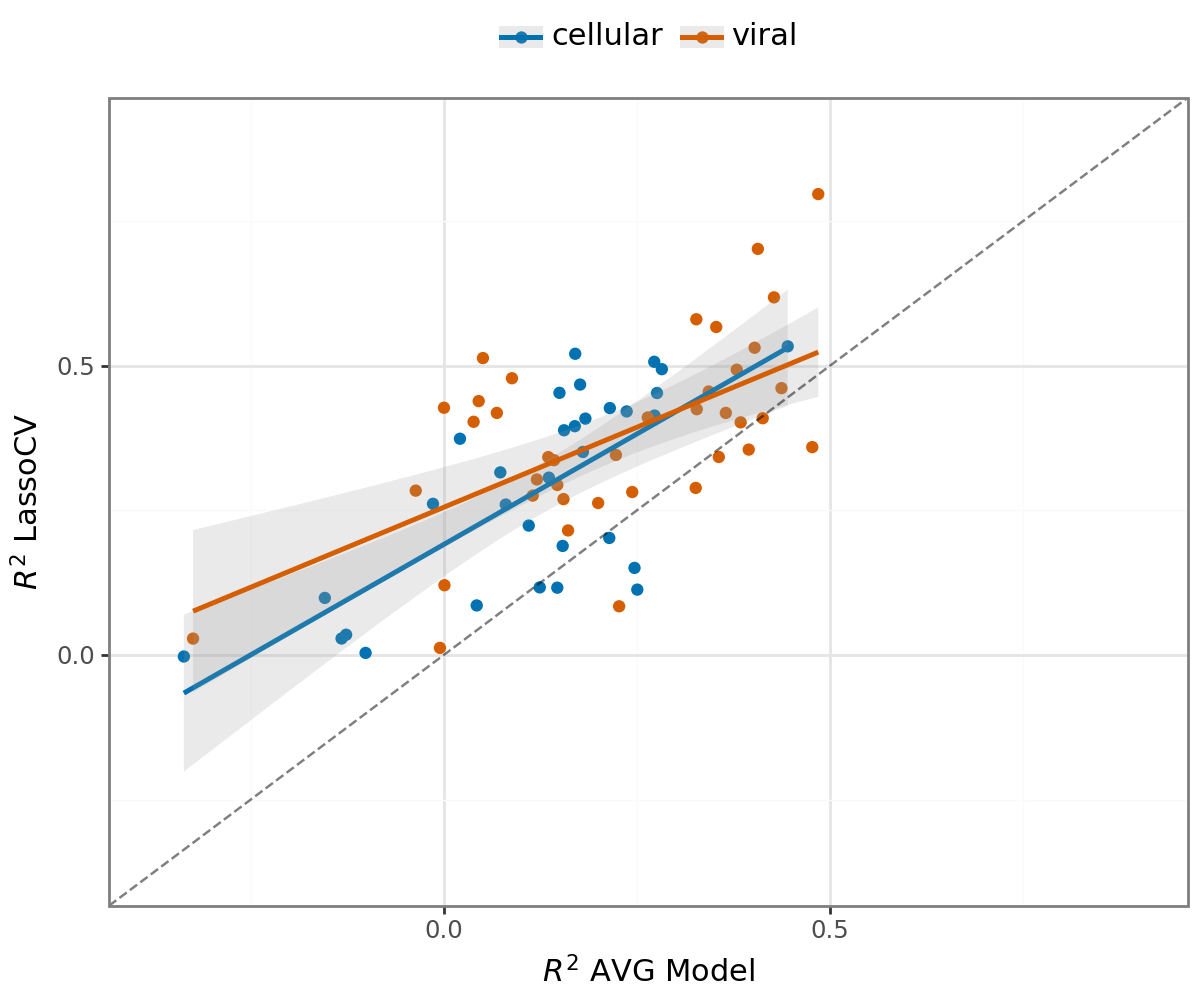

In [10]:
plot = (
    pln.ggplot(res_pivot, pln.aes(y='esm2_viral_full', x='AVG_zscore', color='Source'))
    + pln.scale_color_manual(values={"viral": "#D55E00", "cellular": "#0072B2"})
    + pln.geom_point()
    + pln.geom_smooth(method='lm', se=True,alpha=.2)
    + pln.theme_bw(11)
    + pln.geom_abline(intercept=0, alpha=0.5, linetype='dashed')
    + pln.theme(
        figure_size=(6,5),
        legend_position='top',
        legend_text=pln.element_text(size=11),
        legend_title=pln.element_blank()
    )
    #+ pln.facet_wrap('~Model', scales='fixed')
    + pln.xlim(-0.37, 0.9)
    + pln.ylim(-0.37, 0.9)
    + pln.labs(
        y="$R^2$ LassoCV",
        x="$R^2$ AVG Model"
    )
    )

plot#.save('../experiments/AVG/AVG_x_lassCV.png', dpi=600)

## STD 0.3

In [56]:
lassoCV = pd.DataFrame()
for model in ['esm2_650m', 'esm2_viral_650m_MP15_partial']:
    for source in ['viral', 'cellular']:
        for method in ['pool_split', 'site_split']:
            res_dir_path = f'../experiments/lassoCV_STD_filtered/{model}/{source}/{method}/'
            res = read_results(res_dir_path, 'ESM-2 650M')
            res['Source'] = source
            res['Split'] = method
            res['Model'] = model
            
            lassoCV = pd.concat([lassoCV, res], ignore_index=True)
lassoCV

,Model,Fold,R2_score_train,MAE_score_train,RMSE_score_train,R2_score_test,MAE_score_test,RMSE_score_test,rho_score_train,rho_score_test,num_nonzero_coefs,Dataset,Source,Split
0,esm2_650m,1,0.656345,0.475980,0.584077,0.463366,0.625741,0.739403,0.815524,0.721292,254,CVB3_3A_Alvarez,viral,pool_split
1,esm2_650m,2,0.715563,0.426353,0.528051,0.470422,0.562005,0.754920,0.841007,0.765701,335,CVB3_3A_Alvarez,viral,pool_split
2,esm2_650m,3,0.689555,0.448974,0.555168,0.490323,0.587894,0.722901,0.831753,0.713576,273,CVB3_3A_Alvarez,viral,pool_split
3,esm2_650m,1,0.705165,0.433093,0.542574,0.645106,0.481217,0.597516,0.826941,0.799959,247,CVB3_2A_Alvarez,viral,pool_split
4,esm2_650m,2,0.710862,0.437032,0.542980,0.525936,0.519894,0.660625,0.833422,0.733242,226,CVB3_2A_Alvarez,viral,pool_split
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
883,esm2_viral_650m_MP15_partial,2,0.652718,0.454828,0.591683,0.156850,0.702460,0.898526,0.757064,0.413611,155,HSP82_YEAST_Bolon2016,cellular,site_split
884,esm2_viral_650m_MP15_partial,3,0.396690,0.610130,0.752092,0.083704,0.825191,1.037521,0.588284,0.403170,40,HSP82_YEAST_Bolon2016,cellular,site_split
885,esm2_viral_650m_MP15_partial,1,0.358168,0.634081,0.809562,0.082864,0.724390,0.916747,0.642234,0.350017,109,AMIE_PSEAE_Whitehead,cellular,site_split
886,esm2_viral_650m_MP15_partial,2,0.199567,0.704627,0.880540,0.136055,0.750623,0.972302,0.495244,0.455616,40,AMIE_PSEAE_Whitehead,cellular,site_split


In [57]:
res_avg = pd.DataFrame()
for source in ['viral', 'cellular']:
    for method in ['pool_split', 'site_split']:
        res_dir_path = f'../experiments/AVG_STD_filtered/{source}/{method}/'
        res = read_results(res_dir_path, 'AVG')
        res['Source'] = source
        res['Split'] = method
        res_avg = pd.concat([res_avg, res], ignore_index=True)
res_avg

,Model,Fold,R2_score_train,MAE_score_train,RMSE_score_train,R2_score_test,MAE_score_test,RMSE_score_test,rho_score_train,rho_score_test,Dataset,Source,Split
0,AVG,1,0.348725,0.638989,0.805697,0.192160,0.719061,0.902580,0.579027,0.442385,CVB3_2B_Alvarez,viral,pool_split
1,AVG,2,0.337085,0.652659,0.816309,0.251763,0.673977,0.855765,0.570905,0.479474,CVB3_2B_Alvarez,viral,pool_split
2,AVG,3,0.349736,0.639368,0.804755,0.184654,0.726339,0.907616,0.579802,0.433133,CVB3_2B_Alvarez,viral,pool_split
3,AVG,1,0.424627,0.539291,0.759794,0.537051,0.489591,0.673869,0.620232,0.715001,CVB3_3B_Alvarez,viral,pool_split
4,AVG,2,0.412216,0.559613,0.771281,0.610783,0.456495,0.606953,0.606979,0.771579,CVB3_3B_Alvarez,viral,pool_split
...,...,...,...,...,...,...,...,...,...,...,...,...,...
439,AVG,2,0.000000,0.875556,1.005917,-0.005006,0.835832,0.978543,NaN,NaN,RL401_YEAST_Bolon2013,cellular,site_split
440,AVG,3,0.000000,0.864007,0.988637,-0.000782,0.887424,1.043082,NaN,NaN,RL401_YEAST_Bolon2013,cellular,site_split
441,AVG,1,0.000000,0.902505,0.991693,-0.028436,0.928844,1.034649,NaN,NaN,BLAT_ECOLX_Ranganathan2015,cellular,site_split
442,AVG,2,0.000000,0.905875,1.002061,-0.017960,0.902575,0.993472,NaN,NaN,BLAT_ECOLX_Ranganathan2015,cellular,site_split


In [61]:
res = pd.concat([res_avg, lassoCV.drop('num_nonzero_coefs', axis=1)])
res = res.groupby(['Model', 'Dataset', 'Source', 'Split'], as_index=False).mean()
res = res.query('Split == "pool_split"')
res

,Model,Dataset,Source,Split,Fold,R2_score_train,MAE_score_train,RMSE_score_train,R2_score_test,MAE_score_test,RMSE_score_test,rho_score_train,rho_score_test
0,AVG,AMIE_PSEAE_Whitehead,cellular,pool_split,2.0,0.388771,0.597978,0.783484,0.298236,0.636783,0.830207,0.620496,0.543389
2,AVG,B3VI55_LIPSTSTABLE,cellular,pool_split,2.0,0.313115,0.646530,0.829321,0.214425,0.694585,0.883269,0.552032,0.468140
4,AVG,B3VI55_LIPST_Whitehead2015,cellular,pool_split,2.0,0.261789,0.636266,0.866234,0.148355,0.658894,0.891506,0.469005,0.331665
6,AVG,BG_STRSQ_hmmerbit,cellular,pool_split,2.0,0.340315,0.619558,0.815788,0.000937,0.737156,0.980191,0.516338,0.279848
8,AVG,BLAT_ECOLX_Ostermeier2014,cellular,pool_split,2.0,0.551325,0.505323,0.671751,0.448077,0.550500,0.733876,0.742046,0.668370
...,...,...,...,...,...,...,...,...,...,...,...,...,...
434,esm2_viral_650m_MP15_partial,TPK1_HUMAN_Roth2017,cellular,pool_split,2.0,0.232709,0.722163,0.876269,0.108164,0.775427,0.941897,0.513795,0.351658
436,esm2_viral_650m_MP15_partial,TPMT_HUMAN_Fowler2018,cellular,pool_split,2.0,0.548420,0.511861,0.674499,0.399651,0.580806,0.761892,0.683906,0.583815
438,esm2_viral_650m_MP15_partial,UBC9_HUMAN_Roth2017,cellular,pool_split,2.0,0.566573,0.489925,0.659292,0.386421,0.578807,0.776759,0.786400,0.669632
440,esm2_viral_650m_MP15_partial,UBE4B_MOUSE_Klevit2013_singles,cellular,pool_split,2.0,0.466658,0.550470,0.733780,0.237541,0.622573,0.846648,0.685231,0.474071


In [68]:
rename_map = {
    'esm2_viral_650m_MP15_partial':'esm2_viral_partial', 
    'esm2_viral_650m_MP15':'esm2_viral_full',
    'pool_split':'pooled',
    'site_split':'site',
    }

res.replace(rename_map, inplace=True)

In [69]:
res_pivot = pd.pivot_table(res, index=['Dataset', 'Source', 'Split'], columns='Model', values='R2_score_test').reset_index()
res_pivot 

Model,Dataset,Source,Split,AVG,esm2_650m,esm2_viral_partial
0,AMIE_PSEAE_Whitehead,cellular,pooled,0.298236,0.473088,0.444033
1,B3VI55_LIPSTSTABLE,cellular,pooled,0.214425,0.438942,0.404662
2,B3VI55_LIPST_Whitehead2015,cellular,pooled,0.148355,0.251786,0.241139
3,BG_STRSQ_hmmerbit,cellular,pooled,0.000937,0.399351,0.365126
4,BLAT_ECOLX_Ostermeier2014,cellular,pooled,0.448077,0.672258,0.667551
...,...,...,...,...,...,...
69,TPK1_HUMAN_Roth2017,cellular,pooled,-0.002280,0.120001,0.108164
70,TPMT_HUMAN_Fowler2018,cellular,pooled,0.245216,0.417428,0.399651
71,UBC9_HUMAN_Roth2017,cellular,pooled,0.301814,0.398253,0.386421
72,UBE4B_MOUSE_Klevit2013_singles,cellular,pooled,0.161547,0.249277,0.237541


/stor/work/Wilke/luiz/ViCAM/venv/lib/python3.10/site-packages/plotnine/layer.py:372: PlotnineWarning: geom_point : Removed 2 rows containing missing values.


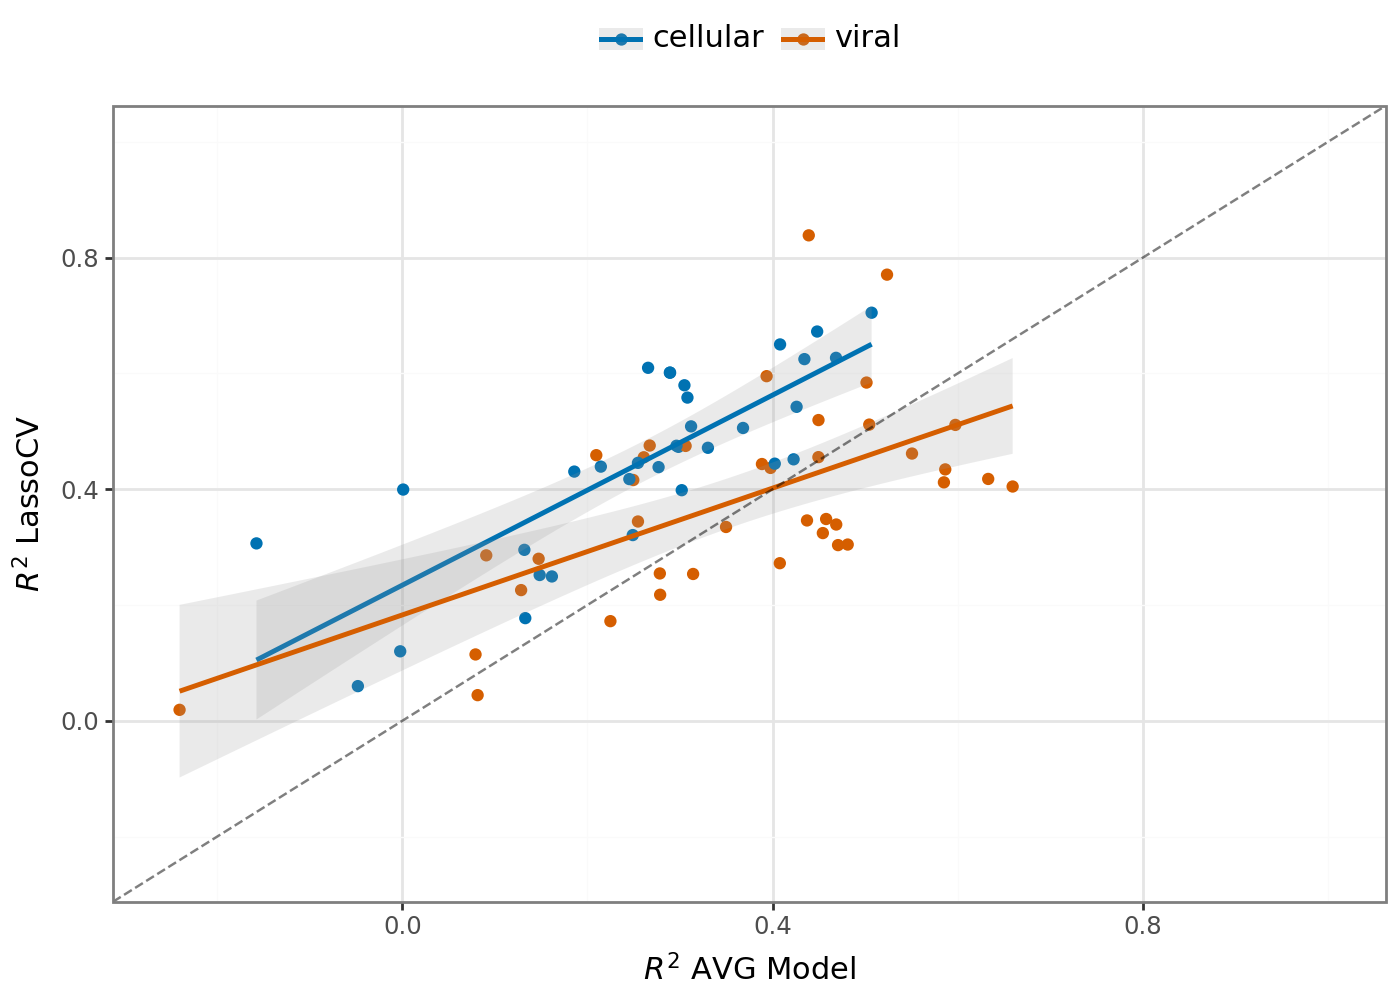

In [70]:
plot = (
    pln.ggplot(res_pivot, pln.aes(y='esm2_650m', x='AVG', color='Source'))
    + pln.scale_color_manual(values={"viral": "#D55E00", "cellular": "#0072B2"})
    + pln.geom_point()
    + pln.geom_smooth(method='lm', se=True,alpha=.2)
    + pln.theme_bw(11)
    + pln.geom_abline(intercept=0, alpha=0.5, linetype='dashed')
    + pln.theme(
        figure_size=(7,5),
        legend_position='top',
        legend_text=pln.element_text(size=11),
        legend_title=pln.element_blank()
    )
    #+ pln.facet_wrap('~Split', scales='fixed')
    + pln.xlim(-0.25, 1)
    + pln.ylim(-0.25, 1)
    + pln.labs(
        y="$R^2$ LassoCV",
        x="$R^2$ AVG Model"
    )
    )

plot

/stor/work/Wilke/luiz/ViCAM/venv/lib/python3.10/site-packages/plotnine/layer.py:372: PlotnineWarning: geom_point : Removed 2 rows containing missing values.


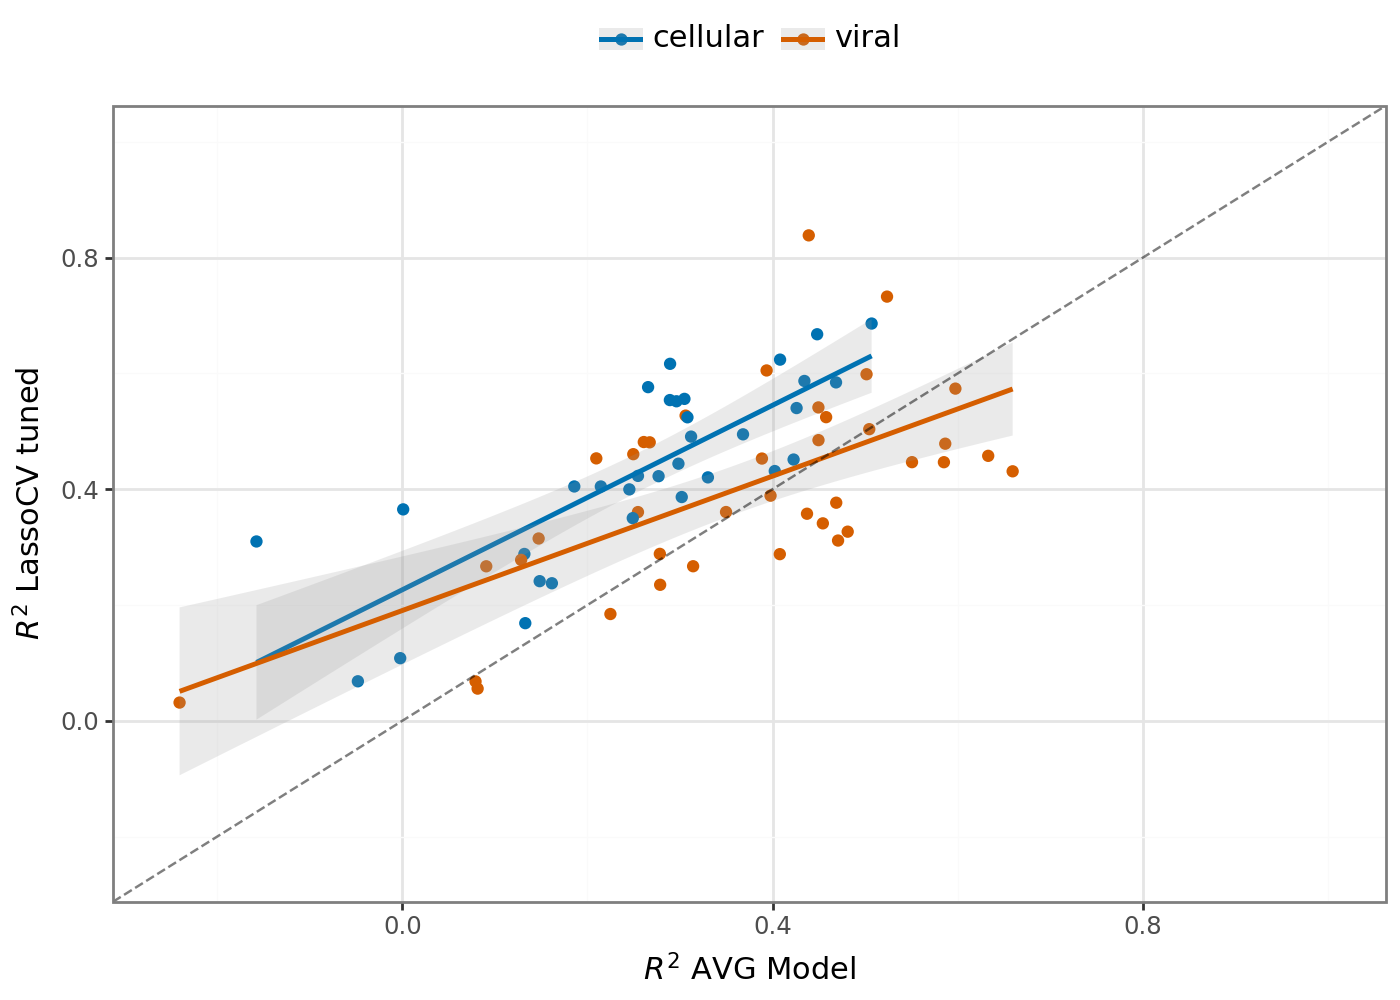

In [71]:
plot = (
    pln.ggplot(res_pivot, pln.aes(y='esm2_viral_partial', x='AVG', color='Source'))
    + pln.scale_color_manual(values={"viral": "#D55E00", "cellular": "#0072B2"})
    + pln.geom_point()
    + pln.geom_smooth(method='lm', se=True,alpha=.2)
    + pln.theme_bw(11)
    + pln.geom_abline(intercept=0, alpha=0.5, linetype='dashed')
    + pln.theme(
        figure_size=(7,5),
        legend_position='top',
        legend_text=pln.element_text(size=11),
        legend_title=pln.element_blank()
    )
    + pln.xlim(-0.25, 1)
    + pln.ylim(-0.25, 1)
    + pln.labs(
        y="$R^2$ LassoCV tuned",
        x="$R^2$ AVG Model"
    )
    )

plot